<a href="https://colab.research.google.com/github/dhaya0/stats_4/blob/main/CSSL_05_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear regression
Let's try loading a dataset a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhayashrir","key":"d94fc16f7673ba32ae140507948d387f"}'}

In [2]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [4]:
!kaggle datasets download -d nikhil7280/student-performance-multiple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
License(s): other
  0% 0.00/48.5k [00:00<?, ?B/s]
100% 48.5k/48.5k [00:00<00:00, 196MB/s]


In [5]:
!unzip student-performance-multiple-linear-regression.zip

Archive:  student-performance-multiple-linear-regression.zip
  inflating: Student_Performance.csv  


In [6]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [7]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'Student_Performance.csv',
 'kaggle.json',
 'student-performance-multiple-linear-regression.zip',
 'sample_data']

The Student_Performance.csv is available!

In [8]:
data = pd.read_csv("Student_Performance.csv") # Read the csv file into a pandas dataframe

In [9]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [10]:
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [11]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [13]:
encoder = LabelEncoder()

data["Extracurricular Activities"] =  encoder.fit_transform(data["Extracurricular Activities"])

In [14]:
data.head() # the first column is the index number

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
# data.Performance\ Index  should work but here the column names have spaces

In [15]:
data["Hours Studied"] # Extracting a specific column

,Hours Studied
0,7
1,4
2,8
3,5
4,7
...,...
9995,1
9996,7
9997,6
9998,9


In [16]:
data.iloc[2] # Extracts specific rows; in this case, the third row

,2
Hours Studied,8.0
Previous Scores,51.0
Extracurricular Activities,1.0
Sleep Hours,7.0
Sample Question Papers Practiced,2.0
Performance Index,45.0


In [17]:
X = data.drop(columns = "Performance Index")
y = data["Performance Index"]

In [20]:
X.sample(5) # Samples a few rows from the data frame (without replacement)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
4285,7,57,1,7,8
2795,5,62,1,9,4
8599,9,93,1,4,4
6530,4,89,1,8,6
425,5,81,0,6,5


In [21]:
y.sample(5)

,Performance Index
3704,32.0
4409,69.0
4724,45.0
487,38.0
188,72.0


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(8000, 5) (8000,) (2000, 5) (2000,)


In [24]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [25]:
model.score(X_train, y_train)

0.9886898790682355

In [26]:
help(model.score)

Help on method score in module sklearn.base:

score(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Return the coefficient of determination of the prediction.

    The coefficient of determination :math:`R^2` is defined as
    :math:`(1 - \frac{u}{v})`, where :math:`u` is the residual
    sum of squares ``((y_true - y_pred)** 2).sum()`` and :math:`v`
    is the total sum of squares ``((y_true - y_true.mean()) ** 2).sum()``.
    The best possible score is 1.0 and it can be negative (because the
    model can be arbitrarily worse). A constant model that always predicts
    the expected value of `y`, disregarding the input features, would get
    a :math:`R^2` score of 0.0.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Test samples. For some estimators this may be a precomputed
        kernel matrix or a list of generic objects instead with shape
        ``(n_samples, n_samples_fitted)``, where ``n_s

In [27]:
predict = np.round(model.predict(X_test), decimals = 1)

In [28]:
pd.DataFrame({"Actual Performance" : y_test, "Predicted Performance" : predict})

,Actual Performance,Predicted Performance
6252,51.0,54.7
4684,20.0,22.6
1731,46.0,47.9
4742,28.0,31.3
4521,41.0,43.0
...,...,...
6412,45.0,46.9
8285,66.0,62.7
7853,16.0,16.8
1095,65.0,63.3


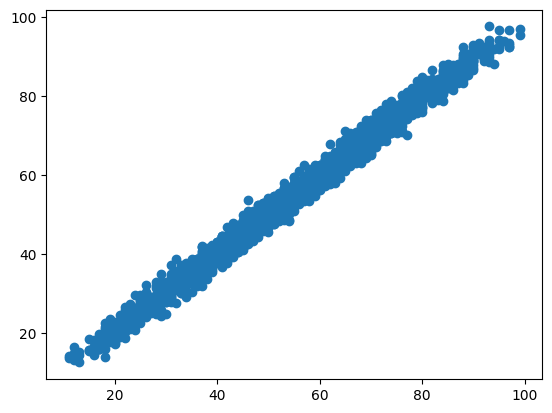

In [29]:
plt.scatter(y_test, predict)
plt.show()

In [30]:
r2_score(y_test,predict)

0.9889704960519785

In [31]:
model.coef_, model.intercept_ # gives all the beta values; parameters

(array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144]),
 np.float64(-33.92194621555638))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

In [ ]:
model.score(X_train, y_train)

In [ ]:
predict = np.round(model.predict(X_test), decimals = 1)

In [ ]:
pd.DataFrame({"Actual Performance" : y_test, "Predicted Performance" : predict})

In [ ]:
plt.scatter(y_test, predict)
plt.show()

In [ ]:
r2_score(y_test,predict)

In [ ]:
model.coef_, model.intercept_

## Try performing simple linear regression on each of these features indvidually

In [32]:
X_single_feature = data.drop(columns=["Sleep Hours", "Previous Scores", "Extracurricular Activities",	"Hours Studied", "Performance Index"])
y = data["Performance Index"]
X_single_feature

,Sample Question Papers Practiced
0,1
1,2
2,2
3,2
4,5
...,...
9995,2
9996,5
9997,5
9998,0


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_single_feature, y, test_size = 0.2, random_state = 42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(8000, 1) (8000,) (2000, 1) (2000,)


In [34]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [35]:
model.score(X_train, y_train)

0.001926123641118882

In [36]:
predict = np.round(model.predict(X_test), decimals = 1)

In [37]:
pd.DataFrame({"Actual Performance" : y_test, "Predicted Performance" : predict})

,Actual Performance,Predicted Performance
6252,51.0,54.5
4684,20.0,56.3
1731,46.0,55.4
4742,28.0,55.4
4521,41.0,55.7
...,...,...
6412,45.0,54.8
8285,66.0,54.8
7853,16.0,54.5
1095,65.0,55.4


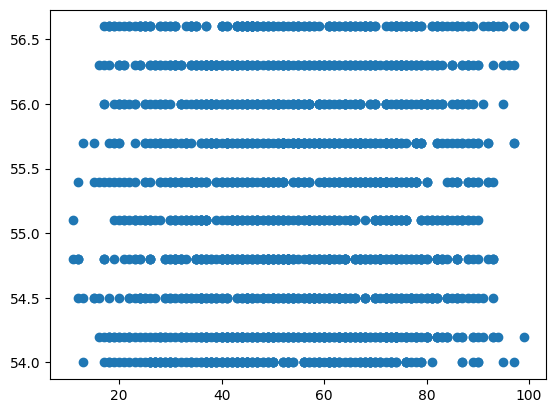

In [38]:
plt.scatter(y_test, predict)
plt.show()

In [39]:
r2_score(y_test,predict)

0.0010087588083272925

In [40]:
model.coef_, model.intercept_

(array([0.29453398]), np.float64(53.951783879471684))

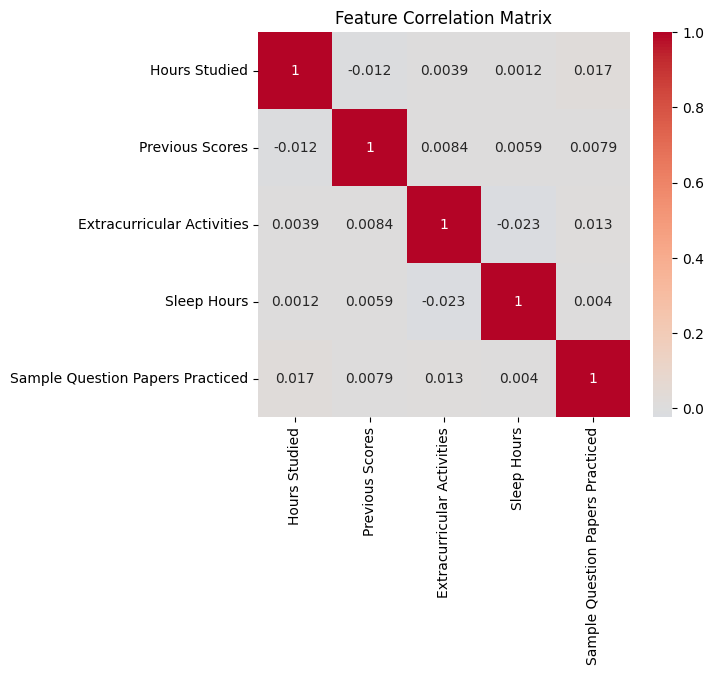

In [41]:
import seaborn as sns
corr = X.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

Let's try adding some correlation between Hours Studied and Question Papers Practiced

In [42]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [43]:
X["Hours Studied Correlated"] = round(X["Hours Studied"] - 0.1*X["Previous Scores"] + 0.1 * np.random.randn(len(X))) # artificially adding correlation
X["Hours Studied Correlated"] = X["Hours Studied Correlated"].clip(lower=0)
X = X.drop(columns=["Hours Studied"])
X

,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Hours Studied Correlated
0,99,1,9,1,0.0
1,82,0,4,2,0.0
2,51,1,7,2,3.0
3,52,1,5,2,-0.0
4,75,0,8,5,-0.0
...,...,...,...,...,...
9995,49,1,4,2,0.0
9996,64,1,8,5,1.0
9997,83,1,8,5,0.0
9998,97,1,7,0,0.0


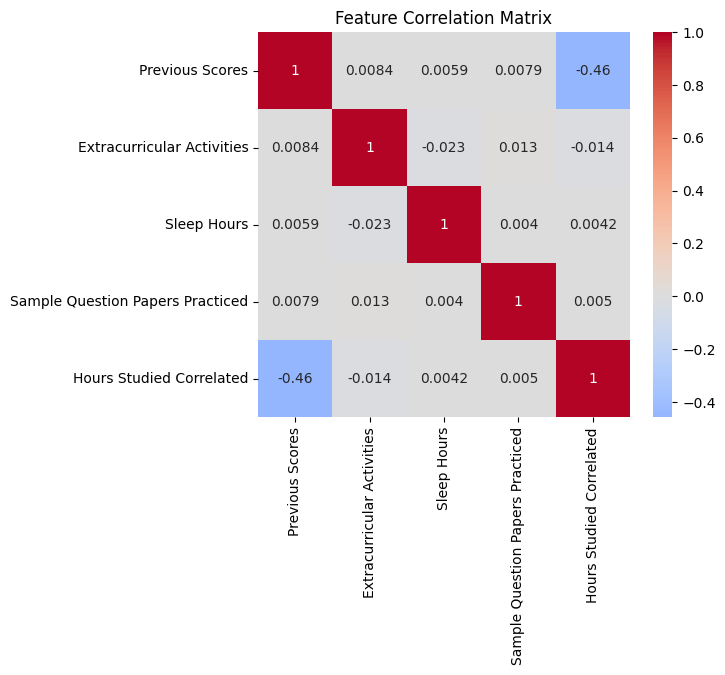

In [44]:
corr = X.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

## Get the coefficients of single and multiple linear regression based on this new data

In [ ]:
X_train_new, X_test_new, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("Multiple Linear Regression:")
print(f"X_train_new shape: {X_train_new.shape}, y_train shape: {y_train.shape}, X_test_new shape: {X_test_new.shape}, y_test shape: {y_test.shape}")

In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train_new,y_train)
print(f"Model R2 score on training data: {model_multi.score(X_train_new, y_train):.4f}")

predict_multi = np.round(model_multi.predict(X_test_new), decimals = 1)
r2_multi = r2_score(y_test,predict_multi)
print(f"Model R2 score on test data: {r2_multi:.4f}")

print("Coefficients for Multiple Linear Regression:")
for feature, coef in zip(X_train_new.columns, model_multi.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model_multi.intercept_:.4f}")

### Simple Linear Regression for each feature with the new `X`

In [ ]:
print("\nSimple Linear Regression for each feature:")
for feature in X.columns:
    X_single = X[[feature]]
    X_train_single, X_test_single, y_train, y_test = train_test_split(X_single, y, test_size = 0.2, random_state = 42)

    model_single = LinearRegression()
    model_single.fit(X_train_single, y_train)

    predict_single = np.round(model_single.predict(X_test_single), decimals = 1)
    r2_single = r2_score(y_test, predict_single)

    print(f"\nFeature: {feature}")
    print(f"  Model R2 score on training data: {model_single.score(X_train_single, y_train):.4f}")
    print(f"  Model R2 score on test data: {r2_single:.4f}")
    print(f"  Coefficient: {model_single.coef_[0]:.4f}")
    print(f"  Intercept: {model_single.intercept_:.4f}")